In [76]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [77]:
data = pd.read_csv('/content/employee_attrition_data.csv')
data

,Employee_ID,Age,Gender,Department,Job_Title,Years_at_Company,Satisfaction_Level,Average_Monthly_Hours,Promotion_Last_5Years,Salary,Attrition
0,0,27,Male,Marketing,Manager,9,0.586251,151,0,60132,0
1,1,53,Female,Sales,Engineer,10,0.261161,221,1,79947,0
2,2,59,Female,Marketing,Analyst,8,0.304382,184,0,46958,1
3,3,42,Female,Engineering,Manager,1,0.480779,242,0,40662,0
4,4,44,Female,Sales,Engineer,10,0.636244,229,1,74307,0
...,...,...,...,...,...,...,...,...,...,...,...
995,995,39,Female,HR,HR Specialist,3,0.377435,239,0,71403,0
996,996,50,Male,Engineering,Manager,1,0.431152,154,0,30181,1
997,997,52,Male,Engineering,Analyst,3,0.647102,206,0,64143,0
998,998,37,Female,HR,HR Specialist,2,0.304813,241,0,74383,1


In [78]:
# Mã hóa các cột phân loại
encoder = LabelEncoder()
data['Gender'] = encoder.fit_transform(data['Gender'])
data['Department'] = encoder.fit_transform(data['Department'])
data['Job_Title'] = encoder.fit_transform(data['Job_Title'])


In [79]:
X = data.drop(columns=['Attrition', 'Employee_ID'])  # Loại bỏ cột 'Attrition' và 'Employee_ID'
y = data['Attrition']  # 'Attrition' là biến mục tiêu

In [80]:
# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [81]:
# Chuẩn hóa dữ liệu (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [82]:
# Xây dựng mô hình Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)

In [83]:
# Huấn luyện mô hình
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [84]:
# Dự đoán trên tập kiểm tra
y_pred = rf.predict(X_test_scaled)

In [85]:
# Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.445

Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.49      0.47       102
           1       0.43      0.40      0.41        98

    accuracy                           0.45       200
   macro avg       0.44      0.44      0.44       200
weighted avg       0.44      0.45      0.44       200



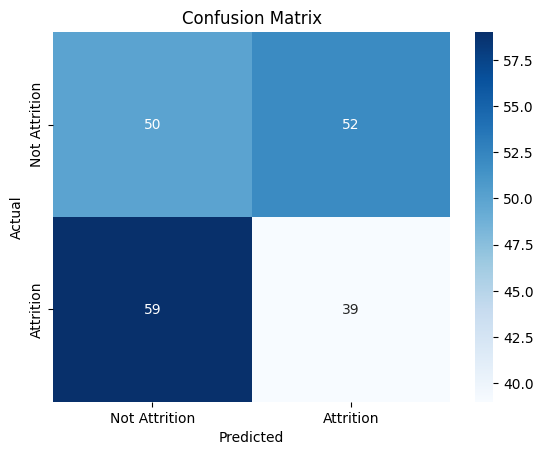

In [86]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Attrition', 'Attrition'], yticklabels=['Not Attrition', 'Attrition'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [102]:
# Chọn đặc trưng quan trọng
selector = SelectFromModel(rf, prefit=True, threshold='mean')
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Huấn luyện lại mô hình với đặc trưng đã chọn
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selected.fit(X_train_selected, y_train)
y_pred_selected = rf_selected.predict(X_test_selected)

# Đánh giá
accuracy = accuracy_score(y_test, y_pred_selected)
print(f"Accuracy with selected features: {accuracy}")

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Accuracy with selected features: 0.52


In [107]:
# Lọc các đặc trưng đã chọn từ dữ liệu gốc
selected_features = X_train.columns[selector.get_support()]

# Tái chuẩn hóa scaler chỉ với các đặc trưng đã chọn
scaler_selected = StandardScaler()
X_train_selected_scaled = scaler_selected.fit_transform(X_train[selected_features])

# Huấn luyện lại mô hình với dữ liệu đã chuẩn hóa và đặc trưng đã chọn
rf_selected.fit(X_train_selected_scaled, y_train)

attrition_by_department = {}
unique_departments = data['Department'].unique()

for department in unique_departments:
    # Lọc dữ liệu cho từng phòng ban
    department_data = data[data['Department'] == department]
    X_department = department_data[selected_features]  # Chỉ giữ các đặc trưng đã chọn
    y_department = department_data['Attrition']

    # Chuẩn hóa dữ liệu với scaler đã được huấn luyện lại
    X_department_scaled = scaler_selected.transform(X_department)

    # Dự đoán
    y_pred_department = rf_selected.predict(X_department_scaled)

    # Tính số lượng và tỷ lệ nghỉ việc
    attrition_count = sum(y_pred_department)
    total_employees = len(X_department)
    attrition_percentage = (attrition_count / total_employees) * 100

    # Lưu kết quả
    attrition_by_department[department] = {
        'Total Employees': total_employees,
        'Attrition Count': attrition_count,
        'Attrition Percentage': attrition_percentage
    }


In [108]:
# Chuyển kết quả sang DataFrame để dễ dàng hiển thị
attrition_df = pd.DataFrame(attrition_by_department).T

attrition_df = attrition_df.sort_values(by='Attrition Percentage', ascending=False)

# Hiển thị kết quả
print(attrition_df)

   Total Employees  Attrition Count  Attrition Percentage
1            206.0            110.0             53.398058
2            191.0             99.0             51.832461
0            204.0            100.0             49.019608
4            209.0            101.0             48.325359
3            190.0             74.0             38.947368


<ipython-input-109-61a259fb4868>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attrition_df.index, y='Attrition Percentage', data=attrition_df, palette='viridis')


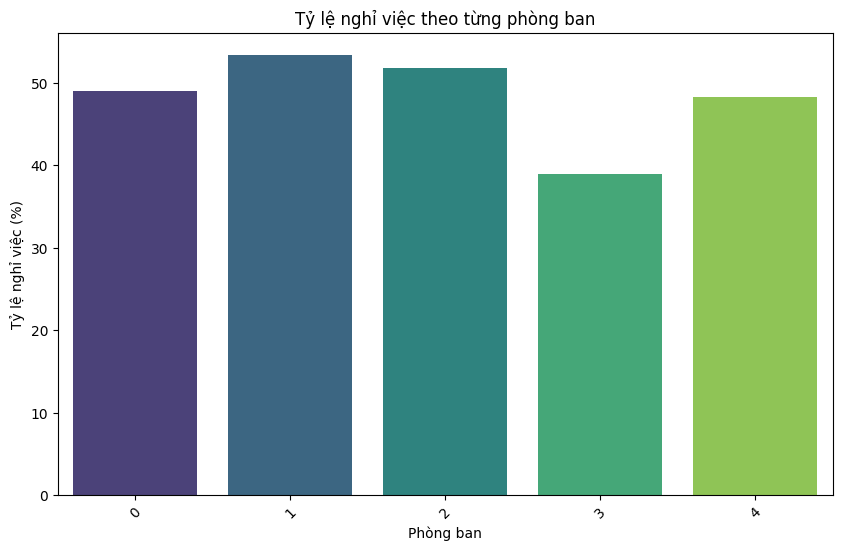

In [109]:
# Vẽ biểu đồ thể hiện tỉ lệ nghỉ việc cho từng phòng ban
plt.figure(figsize=(10, 6))
sns.barplot(x=attrition_df.index, y='Attrition Percentage', data=attrition_df, palette='viridis')
plt.title('Tỷ lệ nghỉ việc theo từng phòng ban')
plt.xlabel('Phòng ban')
plt.ylabel('Tỷ lệ nghỉ việc (%)')
plt.xticks(rotation=45)
plt.show()

In [91]:
!jupyter nbconvert --to html '/content/OLAP_Random_Forest.ipynb'

[NbConvertApp] WARNING | pattern '/content/OLAP_Random_Forest.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=Tru